In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.graphics.mosaicplot import mosaic

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.tree import plot_tree

# Construcción de varios modelos de clasificación

En esta sesión se trabajará con un dataset de e-mails. Algunos son spam y otros no. El objetivo es identificar correctamente son spam.

In [2]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion21/spam_email_dataset.csv'

# Se lee el CSV y se guarda en un pandas DataFrame
df = pd.read_csv(url)

In [3]:
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [4]:
# Ya saben nos gusta conocer las dimensiones de nuestro DataFrame
df.shape

(10000, 20)

In [5]:
# Se aplica el método info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  object 
 2   email_text               10000 non-null  object 
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamation_marks    10000 non-null  int64  
 6   num_links                10000 non-null  int64  
 7   has_suspicious_link      10000 non-null  int64  
 8   num_attachments          10000 non-null  int64  
 9   has_attachment           10000 non-null  int64  
 10  sender_email             10000 non-null  object 
 11  sender_domain            10000 non-null  object 
 12  sender_reputation_score  10000 non-null  float64
 13  email_hour               10000 non-null  int64  
 14  email_day_of_week      

In [6]:
# Sin mucho análisis o justificación se quitarán los NAs
df = df.dropna()

In [7]:
# El tamaño de nuestro dataset
df.shape

(10000, 20)

In [8]:
df.columns

Index(['email_id', 'subject', 'email_text', 'num_words', 'num_characters',
       'num_exclamation_marks', 'num_links', 'has_suspicious_link',
       'num_attachments', 'has_attachment', 'sender_email', 'sender_domain',
       'sender_reputation_score', 'email_hour', 'email_day_of_week',
       'is_weekend', 'num_recipients', 'contains_money_terms',
       'contains_urgency_terms', 'label'],
      dtype='object')

In [9]:
# Veamos la frecuencia de los correos que son spam
# ¿Considera que las clases están desbalanceadas?
df['label'].value_counts()

,count
label,
0,6005
1,3995


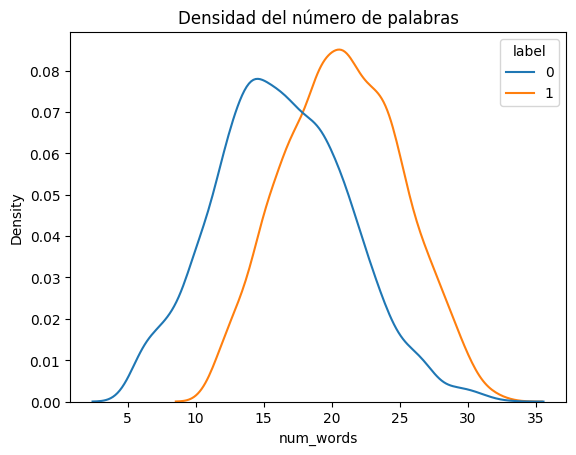

In [10]:
sns.kdeplot(data = df, x = 'num_words', hue = 'label', common_norm = False)

plt.title("Densidad del número de palabras")
plt.show()

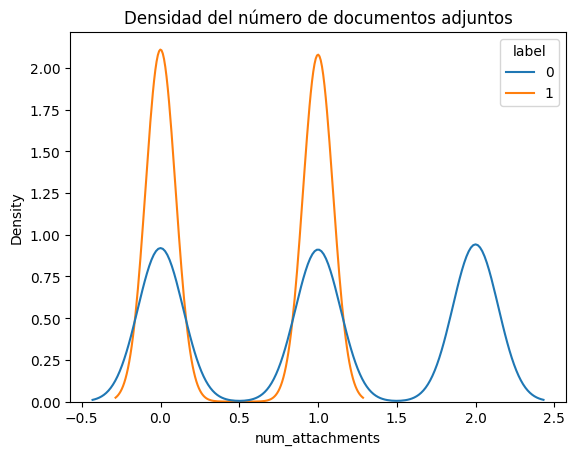

In [11]:
sns.kdeplot(data = df, x = 'num_attachments', hue = 'label', common_norm = False)

plt.title("Densidad del número de documentos adjuntos")
plt.show()

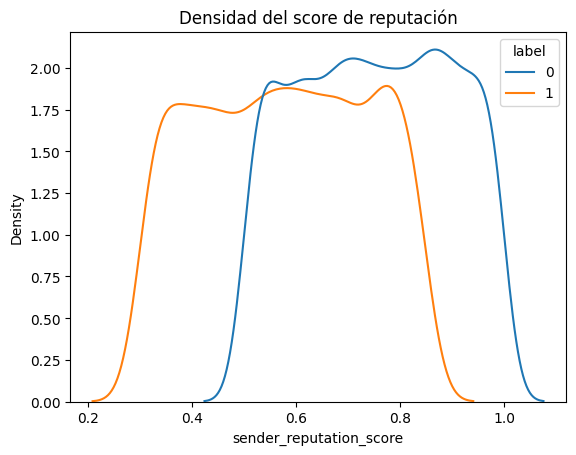

In [12]:
sns.kdeplot(data = df, x = 'sender_reputation_score', hue = 'label', common_norm = False)

plt.title("Densidad del score de reputación")
plt.show()

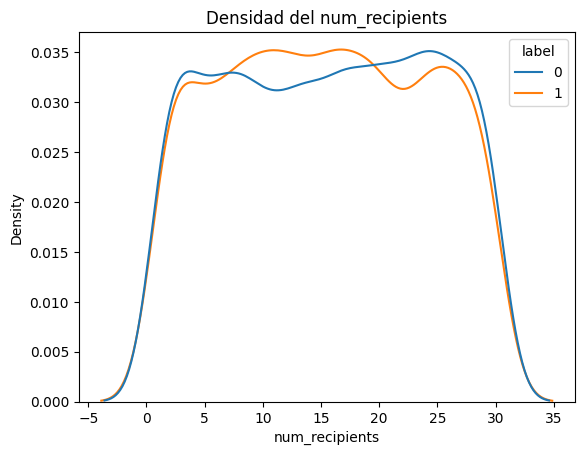

In [13]:
sns.kdeplot(data = df, x = 'num_recipients', hue = 'label', common_norm = False)

plt.title("Densidad del num_recipients")
plt.show()

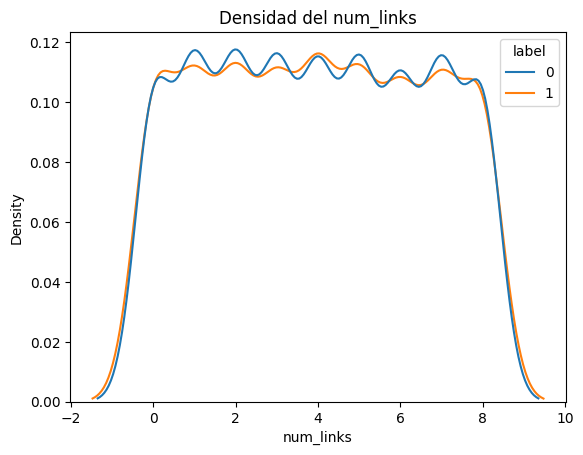

In [14]:
sns.kdeplot(data = df, x = 'num_links', hue = 'label', common_norm = False)

plt.title("Densidad del num_links")
plt.show()

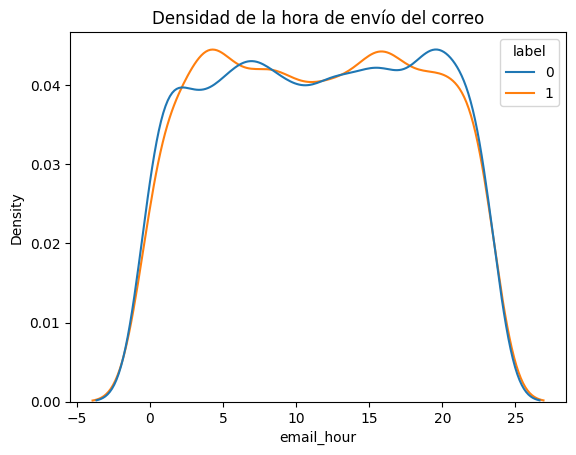

In [15]:
sns.kdeplot(data = df, x = 'email_hour', hue = 'label', common_norm = False)

plt.title("Densidad de la hora de envío del correo")
plt.show()

In [16]:
# Se codifica adecuadamente a la variable para que sea tratada como texto/categoría
df['has_suspicious_link_str'] = df['has_suspicious_link'].astype(str).replace({'0': 'No', '1': 'Sí'})

# Se define una paleta de colores discreto (binario)
color_map = {'No': '#BDC3C7', 'Sí': '#2980B9'}

fig = px.treemap(
    df,
    path = [px.Constant("Total"), 'label', 'has_suspicious_link_str'],
    color = 'has_suspicious_link_str',
    color_discrete_map = color_map,
    title="Análisis de Links Sospechosos (Binario)"
)

# Se mejora un poco la información que aparece en los cuadros
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Cantidad: %{value}<br>Clase: %{parent}',
    textinfo="label+percent parent+value"
)

fig.show()

In [17]:
#'has_attachment'
# Se codifica adecuadamente a la variable para que sea tratada como texto/categoría
df['has_attachment_str'] = df['has_attachment'].astype(str).replace({'0': 'No', '1': 'Sí'})

# Se define una paleta de colores discreto (binario)
color_map = {'No': '#BDC3C7', 'Sí': '#2980B9'}

fig = px.treemap(
    df,
    path = [px.Constant("Total"), 'label', 'has_attachment_str'],
    color = 'has_attachment_str',
    color_discrete_map = color_map,
    title = "Análisis de documentos adjuntos (binario)"
)

# Se mejora un poco la información que aparece en los cuadros
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Cantidad: %{value}<br>Clase: %{parent}',
    textinfo="label+percent parent+value"
)

fig.show()

In [18]:
#'is_weekend'
# Se codifica adecuadamente a la variable para que sea tratada como texto/categoría
df['is_weekend_str'] = df['is_weekend'].astype(str).replace({'0': 'No', '1': 'Sí'})

# Se define una paleta de colores discreto (binario)
color_map = {'No': '#BDC3C7', 'Sí': '#2980B9'}

fig = px.treemap(
    df,
    path = [px.Constant("Total"), 'label', 'is_weekend_str'],
    color = 'is_weekend_str',
    color_discrete_map = color_map,
    title = "Análisis de envío en fin de semana (binario)"
)

# Se mejora un poco la información que aparece en los cuadros
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Cantidad: %{value}<br>Clase: %{parent}',
    textinfo="label+percent parent+value"
)

fig.show()

In [19]:
#'contains_money_terms'
# Se codifica adecuadamente a la variable para que sea tratada como texto/categoría
df['contains_money_terms_str'] = df['contains_money_terms'].astype(str).replace({'0': 'No', '1': 'Sí'})

# Se define una paleta de colores discreto (binario)
color_map = {'No': '#BDC3C7', 'Sí': '#2980B9'}

fig = px.treemap(
    df,
    path = [px.Constant("Total"), 'label', 'contains_money_terms_str'],
    color = 'contains_money_terms_str',
    color_discrete_map = color_map,
    title = "Análisis de con términos monetarios (binario)"
)

# Se mejora un poco la información que aparece en los cuadros
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Cantidad: %{value}<br>Clase: %{parent}',
    textinfo="label+percent parent+value"
)

fig.show()

In [20]:
#'contains_urgency_terms'
# Se codifica adecuadamente a la variable para que sea tratada como texto/categoría
df['contains_urgency_terms_str'] = df['contains_urgency_terms'].astype(str).replace({'0': 'No', '1': 'Sí'})

# Se define una paleta de colores discreto (binario)
color_map = {'No': '#BDC3C7', 'Sí': '#2980B9'}

fig = px.treemap(
    df,
    path = [px.Constant("Total"), 'label', 'contains_urgency_terms_str'],
    color = 'contains_urgency_terms_str',
    color_discrete_map = color_map,
    title = "Análisis de con términos de 'urgente' (binario)"
)

# Se mejora un poco la información que aparece en los cuadros
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Cantidad: %{value}<br>Clase: %{parent}',
    textinfo="label+percent parent+value"
)

fig.show()

In [21]:
#'email_hour'
# Se codifica adecuadamente a la variable para que sea tratada como texto/categoría
df['email_hour_str'] = df['email_hour'].astype(str)

fig = px.treemap(
    df,
    path = [px.Constant("Total"), 'label', 'email_hour_str'],
    color = 'email_hour_str',
    title = "Relación con la hora de envío (binario)"
)

# Se mejora un poco la información que aparece en los cuadros
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Cantidad: %{value}<br>Clase: %{parent}',
    textinfo="label+percent parent+value"
)

fig.show()

## Regresión logística

In [22]:
# Se definen los grupos de variables explicativas
variables_numericas = [
    'num_words', 'num_characters', 'num_exclamation_marks',
    'num_links', 'num_attachments', 'sender_reputation_score', 'num_recipients'
]

variables_categoricas = [
    'has_suspicious_link', 'has_attachment', 'email_hour',
    'is_weekend', 'contains_money_terms', 'contains_urgency_terms'
]

# Se define quienes serán tanto la variable objetivo, como las variables explicativas
y = df['label']
X = df[variables_numericas + variables_categoricas]

# División de datos (entrenamiento y prueba)
# 20% como datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

# Hay que preprocesar a la variables explicativas
# - Numéricas: Escalado (importante en regresión logística)
# - Categóricas: OneHotEncoding (convierte texto/categorías a 0s y 1s)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas),
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), variables_categoricas)
    ]
)

In [23]:
# Se define el modelo y los pasos de pre-procesamiento
modelo_reg_logis = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Se entrena el modelo
modelo_reg_logis.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['num_words',
                                                   'num_characters',
                                                   'num_exclamation_marks',
                                                   'num_links',
                                                   'num_attachments',
                                                   'sender_reputation_score',
                                                   'num_recipients']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['has_suspicious_link',
                                                   'has_attachment',
                                                   'email_hour', 'is_weekend',
                                                   'contains_money_terms',
                                                   'contains_urgency_terms'])])),
                ('classifier', LogisticRegression())])

In [24]:
# Obtenemos las predicciones del modelo sobre las observaciones de entrenamiento
y_pred_train = modelo_reg_logis.predict(X_train)
# Obtenemos las predicciones del modelo sobre las observaciones de test
y_pred_test = modelo_reg_logis.predict(X_test)

In [25]:
# Calculamos una métrica para problemas de clasificación: accuracy
# Porcentaje de observaciones que la predicción fue correcta
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 0.887875
Accuracy en el dataset de prueba: 0.888


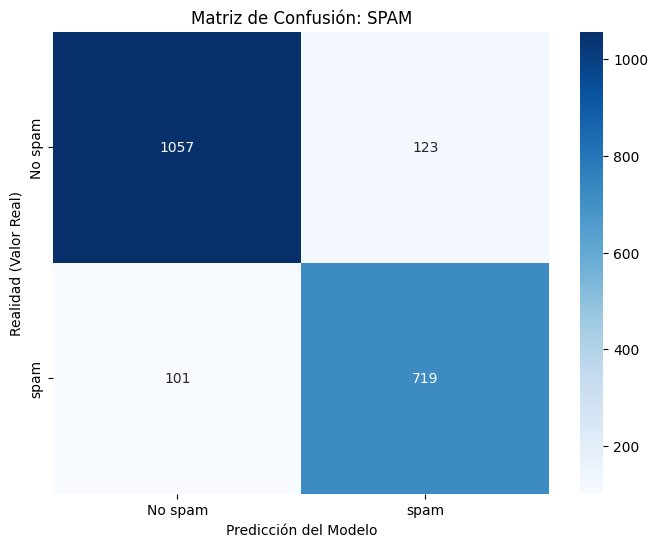

In [26]:
# Se obtiene la matriz de confusión sobre los datos de prueba
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No spam', 'spam'],
            yticklabels=['No spam', 'spam'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: SPAM')
plt.show()

+ Recuérdese que en este caso "1" significa que el correo es spam
+ **Verdaderos positivos** = Observaciones que son 1 y el modelo predijo que son efectivamente 1 = Correos que son spam y el modelo predijo que son spam = 719
+ **Verdaderos negativos** = Observaciones que son 0 y el modelo predijo que son efectivamente 0 = Correos que no son spam y el modelo predijo que no son spam = 1057
+ **Falsos positivos** = Observaciones que son 0 pero el modelo predijo que son 1 = Correos que no son spam pero el modelo predijo que sí lo son = 123
+ **Falsos negativos** = Observaciones que son 1 pero el modelo predijo que son 0 = Correos que son spam pero el modelo predijo que no lo son = 101
+ ¿Qué les interesa controlar? ¿Falsos negativos o Falsos positivos?
+ ¿Qué es peor? ¿Que una persona no lea un correo importante o que una persona lea un correo que es spam?

$$\text{Recall}=\frac{\text{Verdaderos positivos}}{\text{Positivos}} = \frac{TP}{TP + FN}$$

$$\text{Precision} = \frac{\text{Verdaderos positivos}}{\text{El modelo dijo positivos}} = \frac{TP}{TP + FP}$$

$$\text{Tasa Falsos Negativos} = \frac{\text{Falsos negativos}}{\text{Positivos}} = \frac{FN}{TP+FN}$$

$$\text{Tasa Falsos Positivos} = \frac{\text{Falsos positivos}}{\text{Negativos}} = \frac{FP}{TN+FP}$$

$$\text{Especificidad} = \frac{\text{Verdaderos negativos}}{\text{Negativos}} = \frac{TN}{TN+FP}$$

In [27]:
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Tasa Falsos Negativos: {fn / (tp + fn)}")
print(f"Tasa Falsos Positivos: {fp / (tn + fp)}")
print(f"Especificidad: {tn / (tn + fp)}")

Recall: 0.8768292682926829
Precision: 0.8539192399049881
Tasa Falsos Negativos: 0.12317073170731707
Tasa Falsos Positivos: 0.10423728813559321
Especificidad: 0.8957627118644068


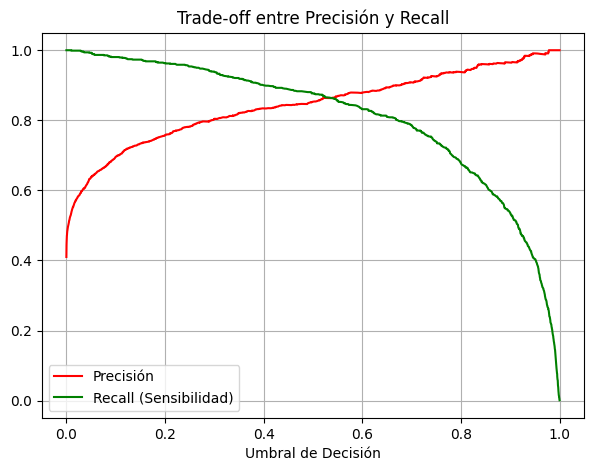

In [28]:
# Recuérdese que se está calculando la probabilidad estimada de ser 1
# En lugar de usar .predict(), usamos .predict_proba()
probabilidades_test = modelo_reg_logis.predict_proba(X_test)[:, 1]

# Se puede graficar tanto la precisión como el recall para cada umbral
# Especificamos explícitamente que el '1' es el evento que nos interesa (ser correo spam)
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precisión", color="red")
plt.plot(thresholds, recall[:-1], label="Recall (Sensibilidad)", color="green")
plt.xlabel("Umbral de Decisión")
plt.title("Trade-off entre Precisión y Recall")
plt.legend()
plt.grid(True)
plt.show()

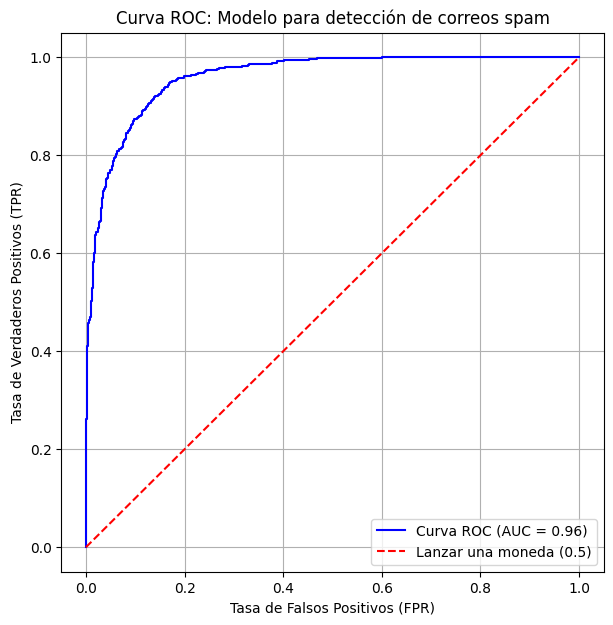

In [29]:
# Recuerda: probabilidades es la columna [:, 1] de predict_proba
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_test)

# Se obtiene el área bajo la curva (AUC)
auc = roc_auc_score(y_test, probabilidades_test)

# Se dibuja la curva ROC
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Lanzar una moneda (0.5)') # Línea de referencia

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo para detección de correos spam')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Se considera a cada umbral como un hiper-parámetro
umbrales = np.linspace(0.1, 0.9, 50) # Probamos 50 umbrales distintos

# Se hará un K-fold cross validation con K = num_folds
num_folds = 5
skf = StratifiedKFold(n_splits = num_folds, shuffle = True, random_state = 2026)

# Matriz para guardar los resultados (Folds x Umbrales)
resultados_f1 = np.zeros((num_folds, len(umbrales)))

# Ciclo de validación cruzada
for fold_idx, (train_index, val_index) in enumerate(skf.split(X, y)):
    X_train_f, X_val_f = X.iloc[train_index], X.iloc[val_index]
    y_train_f, y_val_f = y.iloc[train_index], y.iloc[val_index]

    # Se entrenar el modelo con los datos fuera del fold
    modelo_reg_logis.fit(X_train_f, y_train_f)

    # IMPORTANTE: Verificamos qué columna es la clase 1
    idx_clase_positiva = 1 if modelo_reg_logis.classes_[1] == 1 else 0

    # Se obtienen las probabilidades estimadas de la clase positiva
    probs_val = modelo_reg_logis.predict_proba(X_val_f)[:, idx_clase_positiva]

    # Se prueba con cada uno de los 50 umbrales
    for th_idx, th in enumerate(umbrales):
        # Se clasifica según el umbral actual
        preds = (probs_val >= th).astype(int)

        # Se obtiene una métrica de desempeño
        # En este caso el F1-score
        resultados_f1[fold_idx, th_idx] = f1_score(y_val_f, preds)

# Se promedia y encuentra el "mejor" umbral
f1_promedios = resultados_f1.mean(axis=0)
idx_mejor_umbral = np.argmax(f1_promedios)
mejor_umbral = umbrales[idx_mejor_umbral]

print(f"Mejor umbral: {mejor_umbral:.4f}")
print(f"Mejor F1-Score: {f1_promedios[idx_mejor_umbral]:.4f}")

Mejor umbral: 0.3776
Mejor F1-Score: 0.8604


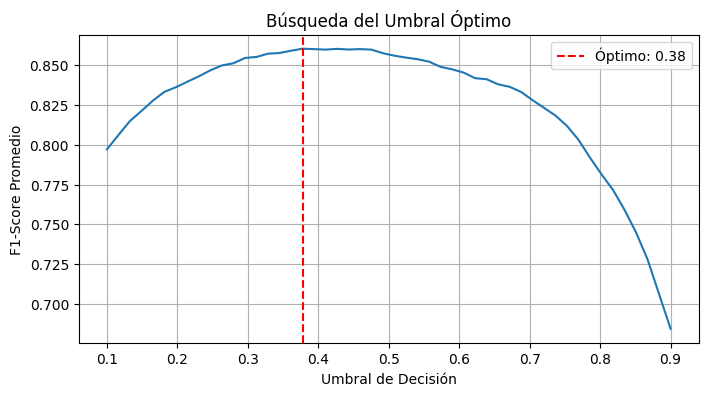

In [31]:
# Visualización (para ver si hay un pico real)
plt.figure(figsize=(8, 4))
plt.plot(umbrales, f1_promedios)
plt.axvline(mejor_umbral, color='red', linestyle='--', label=f'Óptimo: {mejor_umbral:.2f}')
plt.xlabel('Umbral de Decisión')
plt.ylabel('F1-Score Promedio')
plt.title('Búsqueda del Umbral Óptimo')
plt.legend()
plt.grid(True)
plt.show()

Pongamos en acción el modelo con el mejor umbral

In [32]:
probabilidades_test = modelo_reg_logis.predict_proba(X_test)[:, 1]

# Aplicar el umbral óptimo
y_test_pred_custom = (probabilidades_test >= mejor_umbral).astype(int)

In [33]:
y_test_pred_custom

array([1, 0, 1, ..., 1, 1, 1])

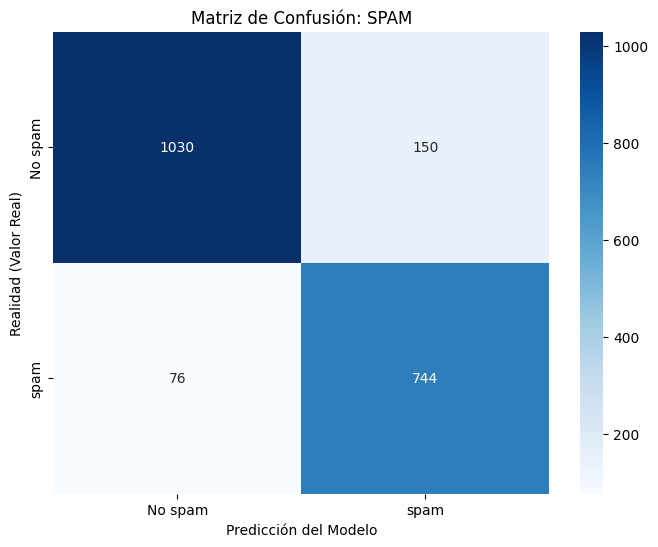

In [34]:
# Se obtiene la nueva matriz de confusión sobre los datos de prueba
cm_custom = confusion_matrix(y_test, y_test_pred_custom)
tn_custom, fp_custom, fn_custom, tp_custom = confusion_matrix(y_test, y_test_pred_custom).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No spam', 'spam'],
            yticklabels=['No spam', 'spam'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: SPAM')
plt.show()

In [35]:
# Se calcula el precision y recall con este nuevo umbral
print(f"Accuracy en el dataset de prueba: {accuracy_score(y_test, y_test_pred_custom)}")
print(f"Recall: {recall_score(y_test, y_test_pred_custom)}")
print(f"Precision: {precision_score(y_test, y_test_pred_custom)}")
print(f"Tasa Falsos Negativos: {fn_custom / (tp_custom + fn_custom)}")
print(f"Tasa Falsos Positivos: {fp_custom / (tn_custom + fp_custom)}")
print(f"Especificidad: {tn_custom / (tn_custom + fp_custom)}")

Accuracy en el dataset de prueba: 0.887
Recall: 0.9073170731707317
Precision: 0.8322147651006712
Tasa Falsos Negativos: 0.09268292682926829
Tasa Falsos Positivos: 0.1271186440677966
Especificidad: 0.8728813559322034


¿Qué tan importante es cada una de las variables en el modelo de regresión logística?

In [36]:
# Se extraen los nombres de las columnas del preprocesador
nombres_features = modelo_reg_logis.named_steps['preprocessor'].get_feature_names_out()
# Se extraen los coeficientes beta (están en la primera fila de .coef_)
coeficientes = modelo_reg_logis.named_steps['classifier'].coef_[0]
# Se ponen en un dataframe
importancia_lr = pd.DataFrame({
    'feature': nombres_features,
    'coeficiente': coeficientes,
    'importancia_absoluta': np.abs(coeficientes) # Para ordenar por impacto real
}).sort_values(by = 'importancia_absoluta', ascending = False)

In [37]:
importancia_lr.head(10)

,feature,coeficiente,importancia_absoluta
8,cat__has_attachment_1,5.299071,5.299071
4,num__num_attachments,-4.016978,4.016978
34,cat__contains_urgency_terms_1,2.279673,2.279673
33,cat__contains_money_terms_1,2.270554,2.270554
0,num__num_words,1.574581,1.574581
5,num__sender_reputation_score,-1.310159,1.310159
1,num__num_characters,-0.516471,0.516471
26,cat__email_hour_18,0.320115,0.320115
27,cat__email_hour_19,-0.275317,0.275317
12,cat__email_hour_4,0.255462,0.255462


## Árbol de decisión individual

In [38]:
# Definición de variables
variables_numericas = [
    'num_words', 'num_characters', 'num_exclamation_marks',
    'num_links', 'num_attachments', 'sender_reputation_score', 'num_recipients'
]

variables_categoricas = [
    'has_suspicious_link', 'has_attachment', 'email_hour',
    'is_weekend', 'contains_money_terms', 'contains_urgency_terms'
]

# Se define quienes serán tanto la variable objetivo, como las variables explicativas
X = df[variables_numericas + variables_categoricas]
y = df['label']

# Preprocesamiento
# Sólo se transforma a las categóricas con OneHotEncoding.
# Con árboles NO es necesario escalar a las variables numéricas
# Las numéricas pasan tal cual (remainder='passthrough')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
    ],
    remainder='passthrough'
)

# Se define el modelo y los pasos de pre-procesamiento
# El modelo será un árbol de decisión individual
modelo_arbol = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state = 2026))
])

# Se define el grid de hiper-parámetros
# Nota: Usamos el prefijo 'classifier__' para referirnos a los parámetros del modelo
param_grid = {
    'classifier__max_depth': [5, 10, 15, 20],
    'classifier__min_samples_split': [5, 10, 15, 20],
    'classifier__min_samples_leaf': [5, 10, 15, 20]
}

# Configuración de Stratified K-Fold
# Se hará un K-fold cross validation con K = num_folds
num_folds = 5
skf = StratifiedKFold(n_splits = num_folds, shuffle = True, random_state = 2026)

# Búsqueda de hiperparámetros con GridSearchCV
# Esto iterará automáticamente sobre las 4x4x4 = 64 combinaciones posibles
grid_search = GridSearchCV(
    estimator = modelo_arbol,
    param_grid = param_grid,
    cv = skf,
    scoring = 'f1', # puedes cambiar de métrica si quieres
    n_jobs = -1,    # Para usar todos los núcleos de la compu
)

# Entrenamientos (acá se hacen un montón de .fit con una sola instrucción)
grid_search.fit(X, y)

# Resultados
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1-Score: {grid_search.best_score_:.4f}")

# El mejor modelo ya está entrenado y listo en grid_search.best_estimator_
mejor_modelo_tree = grid_search.best_estimator_

Mejores parámetros: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 5}
Mejor F1-Score: 0.8759


Pongamos en acción este mejor modelo de árbol de clasificación individual

In [39]:
# IMPORTANTE: Esto es artificial, sólo es para poder compararlo de manera justa con la regresión logística anterior
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

# Obtenemos las predicciones del modelo sobre las observaciones de test
y_pred_test = mejor_modelo_tree.predict(X_test)
probabilidades_test = mejor_modelo_tree.predict_proba(X_test)[:, 1]

# Calculamos una métrica para problemas de clasificación: accuracy
# Porcentaje de observaciones que la predicción fue correcta
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 0.887875
Accuracy en el dataset de prueba: 0.9085


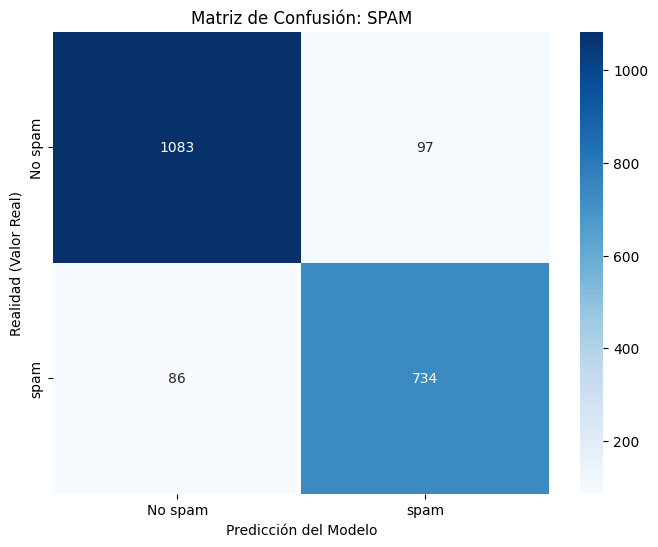

In [40]:
# Se obtiene la matriz de confusión sobre los datos de prueba
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No spam', 'spam'],
            yticklabels=['No spam', 'spam'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: SPAM')
plt.show()

In [41]:
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Tasa Falsos Negativos: {fn / (tp + fn)}")
print(f"Tasa Falsos Positivos: {fp / (tn + fp)}")
print(f"Especificidad: {tn / (tn + fp)}")

Recall: 0.8951219512195122
Precision: 0.8832731648616126
Tasa Falsos Negativos: 0.1048780487804878
Tasa Falsos Positivos: 0.08220338983050847
Especificidad: 0.9177966101694915


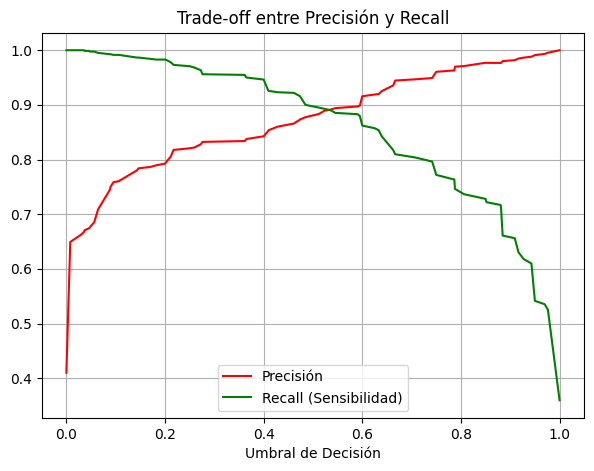

In [42]:
# Se puede graficar tanto la precisión como el recall para cada umbral
# Especificamos explícitamente que el '1' es el evento que nos interesa (spam)
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precisión", color="red")
plt.plot(thresholds, recall[:-1], label="Recall (Sensibilidad)", color="green")
plt.xlabel("Umbral de Decisión")
plt.title("Trade-off entre Precisión y Recall")
plt.legend()
plt.grid(True)
plt.show()

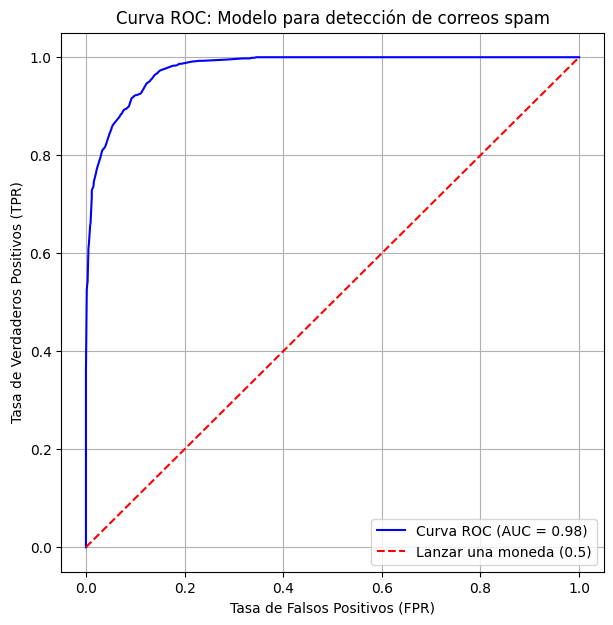

In [43]:
# Se obtiene la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_test)

# Se calcula el área bajo la curva (AUC)
auc = roc_auc_score(y_test, probabilidades_test)

# Dibujamos
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Lanzar una moneda (0.5)') # Línea de referencia

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo para detección de correos spam')
plt.legend()
plt.grid(True)
plt.show()

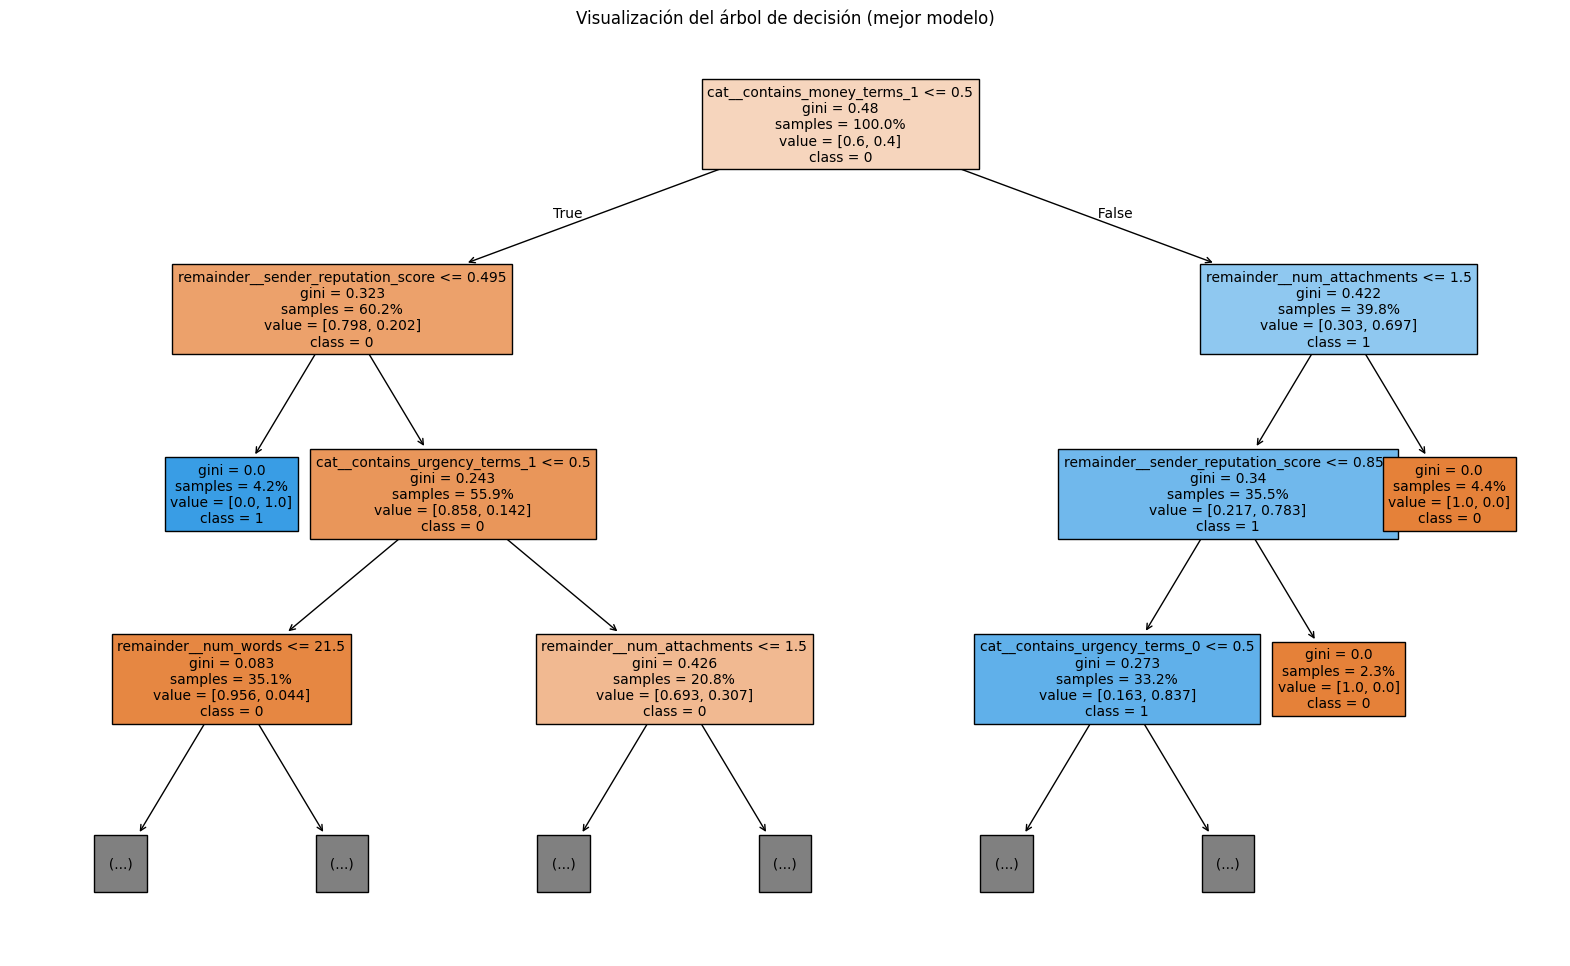

In [44]:
# Veamos una representación gráfica del modelo de árbol entrenado
## Se extraen los nombres de las variables del preprocesador
nombres_features = mejor_modelo_tree.named_steps['preprocessor'].get_feature_names_out()

## Se hace el dibujito de árbol
plt.figure(figsize=(20, 12))
plot_tree(
    mejor_modelo_tree.named_steps['classifier'],
    feature_names=nombres_features,
    class_names=['0', '1'],
    filled = True,             # Colorea los nodos según la clase predominante
    proportion = True,         # Muestra porcentajes en lugar de conteos absolutos
    max_depth = 3,             # Limitamos la vista para que sea legible (opcional)
    fontsize = 10
)

plt.title("Visualización del árbol de decisión (mejor modelo)")
plt.show()

## Random forest

In [45]:
# Definición de variables
variables_numericas = [
    'num_words', 'num_characters', 'num_exclamation_marks',
    'num_links', 'num_attachments', 'sender_reputation_score', 'num_recipients'
]

variables_categoricas = [
    'has_suspicious_link', 'has_attachment', 'email_hour',
    'is_weekend', 'contains_money_terms', 'contains_urgency_terms'
]

# Se define quienes serán tanto la variable objetivo, como las variables explicativas
X = df[variables_numericas + variables_categoricas]
y = df['label']

# Preprocesamiento
# Sólo se transforma a las categóricas con OneHotEncoding.
# Random forest usa varios árboles
# Con árboles NO es necesario escalar a las variables numéricas
# Las numéricas pasan tal cual (remainder='passthrough')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
    ],
    remainder='passthrough'
)

# Se define el modelo y los pasos de pre-procesamiento
# El modelo será un random forest
modelo_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state = 2026))
])

# Se define del grid de hiper-parámetros
# Nota: Usamos el prefijo 'classifier__' para referirnos a los parámetros del modelo
# max_features controla cuántas variables se consideran al buscar el mejor corte
param_grid = {
    'classifier__n_estimators': [10, 100, 500],
    'classifier__max_features': [5, 10, 20],
    'classifier__max_depth': [5, 20]
}

# Configuración de Stratified K-Fold
# Se hará un K-fold cross validation con K = num_folds
num_folds = 5
skf = StratifiedKFold(n_splits = num_folds, shuffle = True, random_state = 2026)

# Búsqueda de hiperparámetros con GridSearchCV
# Esto iterará automáticamente sobre las 3x3x2 = 18 combinaciones posibles
# y además lo hará por cada pliegue i.e. 18 x 5 = 90 entrenamientos (.fit's)
# Aunque en realidad construye muchos árboles porque cada random forest construye 10, 100 o 500 árboles
grid_search_rf = GridSearchCV(
    estimator = modelo_rf,
    param_grid = param_grid,
    cv = skf,
    scoring = 'f1',
    n_jobs = -1
)

# Entrenamientos (acá se hacen un montón de .fit con una sola instrucción)
grid_search_rf.fit(X, y)

# Resultados
print(f"Mejores parámetros: {grid_search_rf.best_params_}")
print(f"Mejor F1-Score: {grid_search_rf.best_score_:.4f}")

# El mejor modelo ya está entrenado y listo en grid_search.best_estimator_
mejor_modelo_rf = grid_search_rf.best_estimator_

Mejores parámetros: {'classifier__max_depth': 5, 'classifier__max_features': 20, 'classifier__n_estimators': 10}
Mejor F1-Score: 0.8813


+ La relación entre `n_estimators` y `max_features` tiene que balancear la fuerza de cada árbol individual y la diversidad de todo el bosque.

+ En random forest los árboles compiten para ser diferentes.

+ Para que un bosque sea mejor que un árbol individual, se necesita que los árboles cometan errores diferentes. Esto se logra limitando las variables que cada árbol puede usar.

+ `max_features` representa la diversidad, i.e. controla cuántas columnas se eligen al azar para cada corte.

+ Si `max_features` es bajo, los árboles son muy diferentes entre sí porque se ven obligados a usar variables "secundarias". Esto aumenta la diversidad (baja la correlación) pero hace que cada árbol sea individualmente más débil.

+ Si `max_features` es alto, los árboles tienden a parecerse mucho porque siempre elegirán la mejor variable disponible. Esto hace que cada árbol sea fuerte, pero el bosque pierde el beneficio de la "sabiduría" colectiva (alta correlación).

+ `n_estimators` se considera como el nivel de "estabilidad", pues a medida que se aumenta este número, el error del bosque se estabiliza porque los errores aleatorios de los árboles individuales se "cancelan entre sí".

+ Por ejemplo, si se tiene muchísimas variables correlacionadas, `max_features` debe ser bajo y  `n_estimators alto. Se evita overfitting.

+ Por el contrario, cuando se tienes pocas variables (columnas) y todas son muy importantes, `max_features` debe ser alto y `n_estimators` bajo. La idea es que el bosque se comporte casi como un árbol único pero un más estable.

+ A diferencia de otros parámetros, `n_estimators` no causa overfitting por sí solo. Puedes `n_estimators` grande y el modelo no empeorará, solo se volverá más lento.

+ Sin embargo, el valor óptimo de `max_features` suele depender de cuántos árboles se tengan.

  + Con pocos árboles, se necesitas que cada uno sea bastante fuerte (i.e. `max_features` más alto).

  + Con muchos árboles, se puede permitir que cada árbol sea débil pero diverso (i.e. `max_features` más bajo), confiando en que el promedio final será preciso.

Pongamos en acción este mejor modelo de random forest

In [46]:
# IMPORTANTE: Esto es artificial, sólo es para poder compararlo de manera justa con la regresión logística anterior
# y el árbol de decisión individual anterior
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

# Obtenemos las predicciones del modelo sobre las observaciones de test
y_pred_test = mejor_modelo_rf.predict(X_test)
probabilidades_test = mejor_modelo_rf.predict_proba(X_test)[:, 1]

# Calculamos una métrica para problemas de clasificación: accuracy
# Porcentaje de observaciones que la predicción fue correcta
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de prueba: 0.905


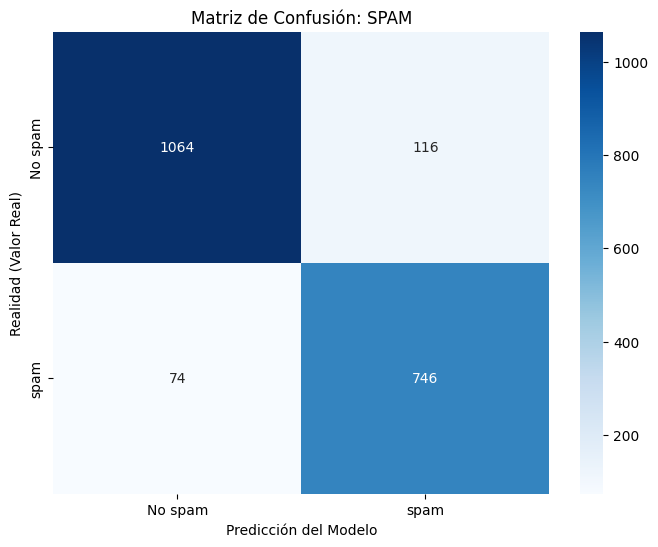

In [47]:
# Se obtiene la matriz de confusión sobre los datos de prueba
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No spam', 'spam'],
            yticklabels=['No spam', 'spam'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: SPAM')
plt.show()

In [48]:
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Tasa Falsos Negativos: {fn / (tp + fn)}")
print(f"Tasa Falsos Positivos: {fp / (tn + fp)}")
print(f"Especificidad: {tn / (tn + fp)}")

Recall: 0.9097560975609756
Precision: 0.8654292343387471
Tasa Falsos Negativos: 0.09024390243902439
Tasa Falsos Positivos: 0.09830508474576272
Especificidad: 0.9016949152542373


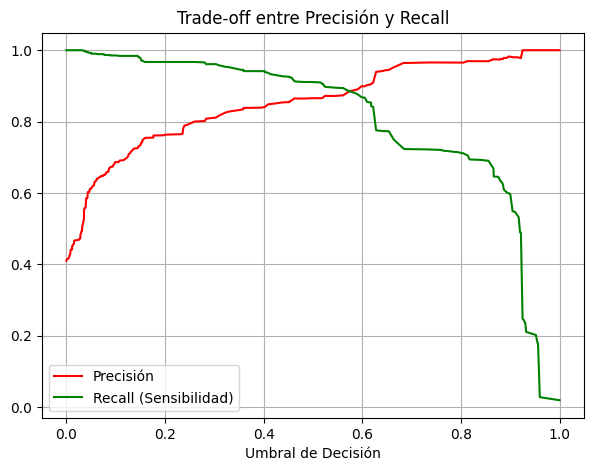

In [49]:
# Se puede graficar tanto la precisión como el recall para cada umbral
# Especificamos explícitamente que el '1' es el evento que nos interesa (spam)
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precisión", color="red")
plt.plot(thresholds, recall[:-1], label="Recall (Sensibilidad)", color="green")
plt.xlabel("Umbral de Decisión")
plt.title("Trade-off entre Precisión y Recall")
plt.legend()
plt.grid(True)
plt.show()

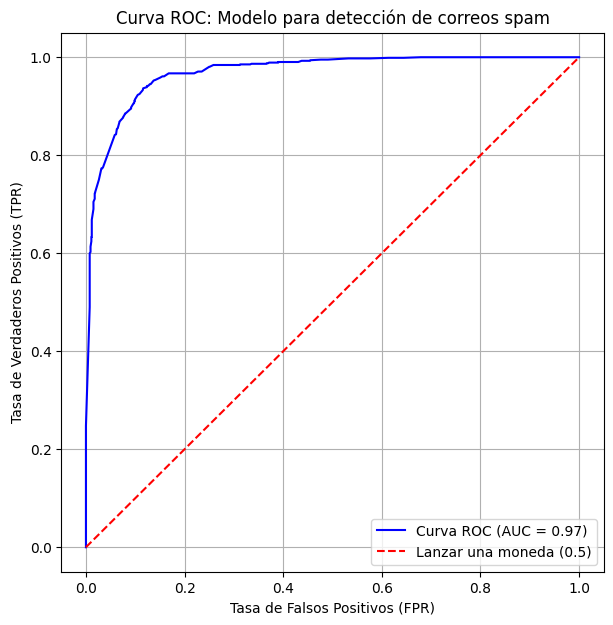

In [50]:
# Se obtiene la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_test)

# Se calcula el área bajo la curva (AUC)
auc = roc_auc_score(y_test, probabilidades_test)

# Dibujamos
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Lanzar una moneda (0.5)') # Línea de referencia

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo para detección de correos spam')
plt.legend()
plt.grid(True)
plt.show()

¿Qué tan importante es cada variable explicativa en el modelo?

In [51]:
# Se extraen los nombres de las columnas del preprocesador
nombres_features = mejor_modelo_rf.named_steps['preprocessor'].get_feature_names_out()
# Se extraen las importancias de cada variable en el random_forest
importancias_rf = mejor_modelo_rf.named_steps['classifier'].feature_importances_
# Se ponen en un dataframe
df_imp = pd.DataFrame({
    'feature': nombres_features,
    'importance': importancias_rf
}).sort_values(by = 'importance', ascending = False)

In [52]:
df_imp.head(10)

,feature,importance
39,remainder__sender_reputation_score,0.294266
30,cat__contains_money_terms_0,0.168006
38,remainder__num_attachments,0.156039
31,cat__contains_money_terms_1,0.140353
33,cat__contains_urgency_terms_1,0.101584
32,cat__contains_urgency_terms_0,0.067900
34,remainder__num_words,0.043268
35,remainder__num_characters,0.027371
2,cat__has_attachment_0,0.000732
3,cat__has_attachment_1,0.000195


## Boosting (Adaptative boosting a.k.a. AdaBoost)

In [53]:
# Definición de variables
variables_numericas = [
    'num_words', 'num_characters', 'num_exclamation_marks',
    'num_links', 'num_attachments', 'sender_reputation_score', 'num_recipients'
]

variables_categoricas = [
    'has_suspicious_link', 'has_attachment', 'email_hour',
    'is_weekend', 'contains_money_terms', 'contains_urgency_terms'
]

# Se define quienes serán tanto la variable objetivo, como las variables explicativas
X = df[variables_numericas + variables_categoricas]
y = df['label']

# Preprocesamiento
# Sólo se transforma a las categóricas con OneHotEncoding.
# Random forest usa varios árboles
# Con árboles NO es necesario escalar a las variables numéricas
# Las numéricas pasan tal cual (remainder='passthrough')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
    ],
    remainder='passthrough'
)

# Se define el modelo y los pasos de pre-procesamiento
# El modelo será un random forest
modelo_boost = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        estimator = DecisionTreeClassifier(max_depth=1),
        random_state = 2026
    ))
])

# Se define del grid de hiper-parámetros
# Nota: Usamos el prefijo 'classifier__' para referirnos a los parámetros del modelo
# n_estimators: número de modelos secuenciales
# learning_rate: contribución de cada modelo (reduce el riesgo de overfitting)
param_grid = {
    'classifier__n_estimators': [20, 100, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

# Configuración de Stratified K-Fold
# Se hará un K-fold cross validation con K = num_folds
num_folds = 5
skf = StratifiedKFold(n_splits = num_folds, shuffle = True, random_state = 2026)

# Búsqueda de hiperparámetros con GridSearchCV
# Esto iterará automáticamente sobre las 3x4 = 12 combinaciones posibles
# y además lo hará por cada pliegue i.e. 12 x 5 = 60 entrenamientos (.fit's)

grid_search_boost = GridSearchCV(
    estimator = modelo_boost,
    param_grid = param_grid,
    cv = skf,
    scoring = 'f1',
    n_jobs = -1
)

# Entrenamientos (acá se hacen un montón de .fit con una sola instrucción)
grid_search_boost.fit(X, y)

# Resultados
print(f"Mejores parámetros: {grid_search_boost.best_params_}")
print(f"Mejor F1-Score: {grid_search_boost.best_score_:.4f}")

# El mejor modelo ya está entrenado y listo en grid_search.best_estimator_
mejor_modelo_boost = grid_search_boost.best_estimator_

Mejores parámetros: {'classifier__learning_rate': 0.5, 'classifier__n_estimators': 500}
Mejor F1-Score: 0.8830


+ La relación entre `n_estimators` y `learning_rate` en algoritmos de Boosting (como AdaBoost o Gradient Boosting) es otro caso del No-Free Lunch Theorem que se conoce como "trade-off de aprendizaje".

+ Regla de oro teórica: A menor `learning_rate`, mayor debe ser el `n_estimators`.

+ La learning rate ($\eta$) controla qué tan "fuerte" es la corrección que hace cada nuevo árbol sobre los errores de los anteriores. Si es bajo (ej. 0.01), el modelo avanza con "pasitos de bebé"; y el `n_estimators` se puente interpretar como cuántos de esos pasos se le permite dar al modelo.

  + Si se usa un learning rate muy bajo pero pocos árboles individuales, el modelo se quedará "a mitad de camino" y no llegará a aprender los patrones complejos de los datos (underfitting).

+ No siempre "más es mejor". Si se eleva `n_estimators` infinitamente, incluso con un `learning_rate` bajo, eventualmente el modelo empezará a memorizar el ruido de los datos de entrenamiento y el F1-Score en validación empezará a caer.

  + Con un `learning_rate` alto pero con `n_estimators` bajo, se "aprende muy rápido", pero suele ser inestable y puede pasarse de largo la solución óptima (overfitting u oscilaciones).

  + Con un `learning_rate` bajo pero con `n_estimators` alto, se "aprende muy lento" pero de forma relativamente precisa. Suele lograr mejores resultados de generalización, aunque tarda mucho más en entrenar.

Pongamos en acción este mejor modelo de boosting (AdaBoosting)

In [54]:
# IMPORTANTE: Esto es artificial, sólo es para poder compararlo de manera justa con la regresión logística anterior
# el árbol de decisión individual anterior y el random forest anterior
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

# Obtenemos las predicciones del modelo sobre las observaciones de test
y_pred_test = mejor_modelo_boost.predict(X_test)
probabilidades_test = mejor_modelo_boost.predict_proba(X_test)[:, 1]

# Calculamos una métrica para problemas de clasificación: accuracy
# Porcentaje de observaciones que la predicción fue correcta
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de prueba: 0.9055


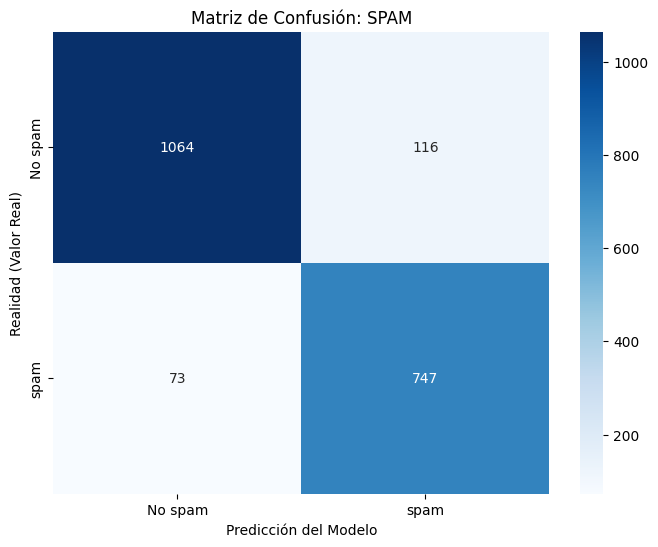

In [55]:
# Se obtiene la matriz de confusión sobre los datos de prueba
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No spam', 'spam'],
            yticklabels=['No spam', 'spam'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: SPAM')
plt.show()

In [56]:
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Tasa Falsos Negativos: {fn / (tp + fn)}")
print(f"Tasa Falsos Positivos: {fp / (tn + fp)}")
print(f"Especificidad: {tn / (tn + fp)}")

Recall: 0.9109756097560976
Precision: 0.86558516801854
Tasa Falsos Negativos: 0.08902439024390243
Tasa Falsos Positivos: 0.09830508474576272
Especificidad: 0.9016949152542373


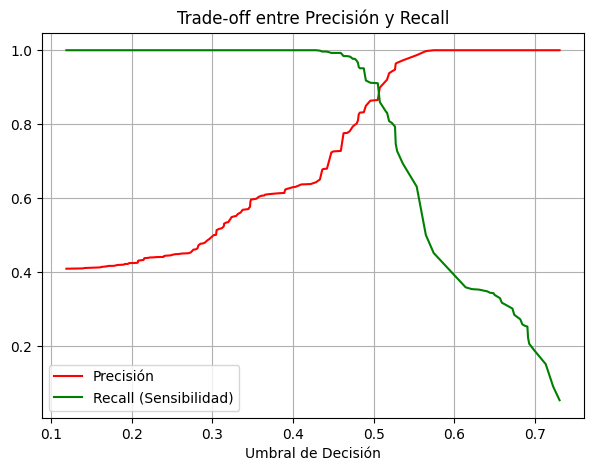

In [57]:
# Se puede graficar tanto la precisión como el recall para cada umbral
# Especificamos explícitamente que el '1' es el evento que nos interesa (spam)
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precisión", color="red")
plt.plot(thresholds, recall[:-1], label="Recall (Sensibilidad)", color="green")
plt.xlabel("Umbral de Decisión")
plt.title("Trade-off entre Precisión y Recall")
plt.legend()
plt.grid(True)
plt.show()

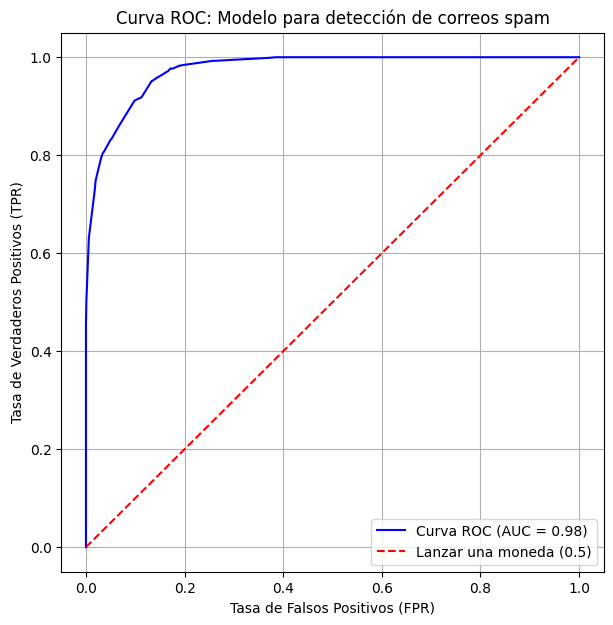

In [58]:
# Se obtiene la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_test)

# Se calcula el área bajo la curva (AUC)
auc = roc_auc_score(y_test, probabilidades_test)

# Dibujamos
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Lanzar una moneda (0.5)') # Línea de referencia

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo para detección de correos spam')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
# Se extraen los nombres de las columnas del preprocesador
nombres_features = mejor_modelo_boost.named_steps['preprocessor'].get_feature_names_out()
# Se extraen las importancias de cada variable en el AdaBoosting
importancias_ada = mejor_modelo_boost.named_steps['classifier'].feature_importances_
# Se ponen en un dataframe
df_imp_boost = pd.DataFrame({
    'feature': nombres_features,
    'importance': importancias_ada
}).sort_values(by = 'importance', ascending = False)

In [60]:
df_imp_boost.head(10)

,feature,importance
39,remainder__sender_reputation_score,0.434409
38,remainder__num_attachments,0.272127
34,remainder__num_words,0.146622
35,remainder__num_characters,0.052505
30,cat__contains_money_terms_0,0.048462
32,cat__contains_urgency_terms_0,0.038732
33,cat__contains_urgency_terms_1,0.007142
1,cat__has_suspicious_link_1,0.000000
0,cat__has_suspicious_link_0,0.000000
8,cat__email_hour_4,0.000000
